<a href="https://colab.research.google.com/github/AslesaLamsal/AI-and-Machine-Learning/blob/main/2407798_AslesaLamsal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2407798_AslesaLamsal

# (Sentiment Analysis) Text Classification with RNN.

# Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Extracting ZIP File

In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Coursework/7. Racist Sexist or Not Dataset-20260430T075109Z-3-001.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


# Installing Requirement Libraries

In [3]:
!pip install wordcloud contractions gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00


In [4]:
!pip install gradio --quiet

# Importing All Necessary Libraries

In [5]:
import os, re, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import contractions

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (accuracy_score, confusion_matrix,
                                     classification_report, ConfusionMatrixDisplay)
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import f1_score as f1

import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.layers import Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import (Embedding, SimpleRNN, LSTM,
                                       Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import gensim.downloader as gensim_api


# Load Dataset

In [6]:
TRAIN_PATH = "/content/data/7. Racist Sexist or Not Dataset/train_racisit.csv"
TEST_PATH  = "/content/data/7. Racist Sexist or Not Dataset/test_racisit.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
print("\nTrain columns:", train_df.columns.tolist())
print("Test  columns:", test_df.columns.tolist())
train_df.head()

Train shape : (31962, 3)
Test  shape : (17197, 2)

Train columns: ['id', 'label', 'tweet']
Test  columns: ['id', 'tweet']


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


# Prepare Data and Class Distribution

In [7]:
test_raw = test_df[['id', 'tweet']].copy()
data = train_df[['tweet', 'label']].copy()
data['label'] = data['label'].astype(int)

print(f"Labelled data   (train_racisit.csv) : {len(data):,} tweets")
print(f"Inference data  (test_racisit.csv)  : {len(test_raw):,} tweets (no labels)")
print("\nClass distribution:")
print(data['label'].value_counts())
print("  0 = Non-Racist/Sexist")
print("  1 = Racist/Sexist")

Labelled data   (train_racisit.csv) : 31,962 tweets
Inference data  (test_racisit.csv)  : 17,197 tweets (no labels)

Class distribution:
label
0    29720
1     2242
Name: count, dtype: int64
  0 = Non-Racist/Sexist
  1 = Racist/Sexist


# Handle Missing Values

In [9]:
print("Missing values:")
print(data.isnull().sum())
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)


Missing values:
tweet    0
label    0
dtype: int64


# Visualize Class/Length Distribution

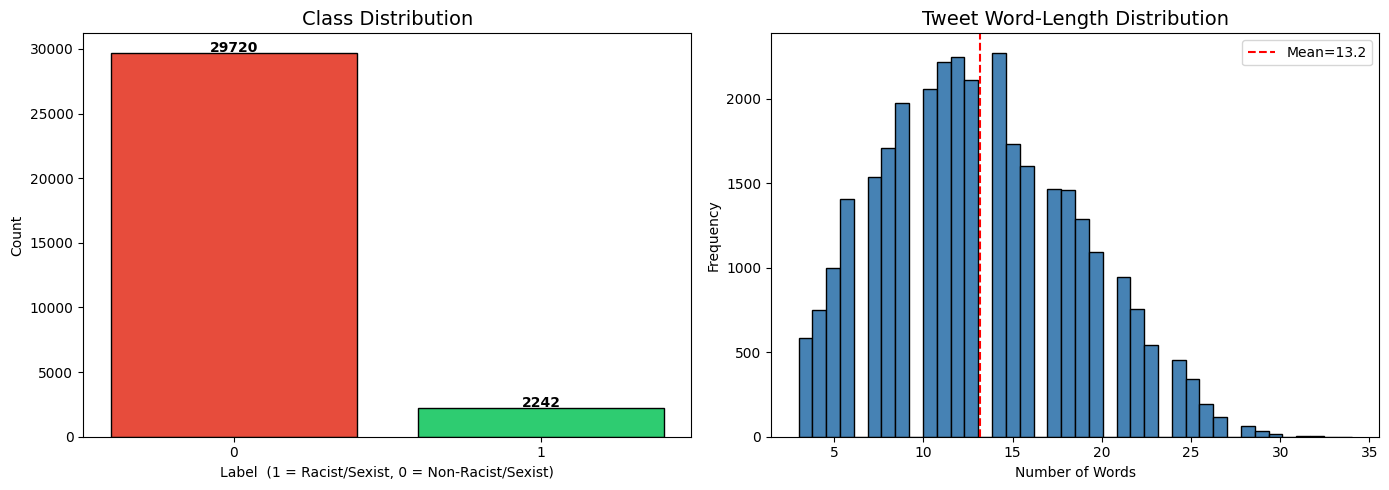


Average tweet length : 13.2 words
Max tweet length      : 34 words


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = data['label'].value_counts()
axes[0].bar(counts.index.astype(str), counts.values,
            color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xlabel('Label  (1 = Racist/Sexist, 0 = Non-Racist/Sexist)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

data['tweet_len'] = data['tweet'].astype(str).apply(lambda x: len(x.split()))
axes[1].hist(data['tweet_len'], bins=40, color='steelblue', edgecolor='black')
axes[1].axvline(data['tweet_len'].mean(), color='red',
                linestyle='--', label=f"Mean={data['tweet_len'].mean():.1f}")
axes[1].set_title('Tweet Word-Length Distribution', fontsize=14)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\nAverage tweet length : {data['tweet_len'].mean():.1f} words")
print(f"Max tweet length      : {data['tweet_len'].max()} words")

# Text Cleaning Function

# Lowercase, URLs, Mentions, Stopwords, Lemmatization

In [13]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Expand contractions
    text = contractions.fix(text)
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove @mentions fully
    text = re.sub(r'@\w+', '', text)
    # Remove only # symbol, keep the word
    text = re.sub(r'#', '', text)
    # Remove remaining punctuation / special characters / numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # Tokenise → remove stopwords → lemmatise
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in STOP_WORDS and len(w) > 1]
    return ' '.join(tokens)

data['cleaned_tweet'] = data['tweet'].apply(clean_text)

preview = data[['tweet','cleaned_tweet','label']].head(5)
pd.set_option('display.max_colwidth', 80)
print("\nBefore / After cleaning preview:")
preview


Before / After cleaning preview:


,tweet,cleaned_tweet,label
0,@user when a father is dysfunctional and is so selfish he drags his kids in...,father dysfunctional selfish drag kid dysfunction run,0
1,@user @user thanks for #lyft credit i can't use cause they don't offer wheel...,thanks lyft credit cannot use offer wheelchair van pdx disapointed getthanked,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in urð±!!! ðððð ð¦...,model love take time,0
4,factsguide: society now #motivation,factsguide society motivation,0


# Remove Empty Tweets After Cleaning

In [14]:
data = data[data['cleaned_tweet'].str.strip() != '']
data.reset_index(drop=True, inplace=True)
print(f"Dataset size after cleaning: {len(data)}")

Dataset size after cleaning: 31922


# Word Cloud Visualisation By Class

In [ ]:
all_words = ' '.join(data['cleaned_tweet'])
wc_all = WordCloud(width=800, height=400,
                   background_color='white',
                   max_words=100).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words — All Tweets', fontsize=14, fontweight='bold')
plt.show()

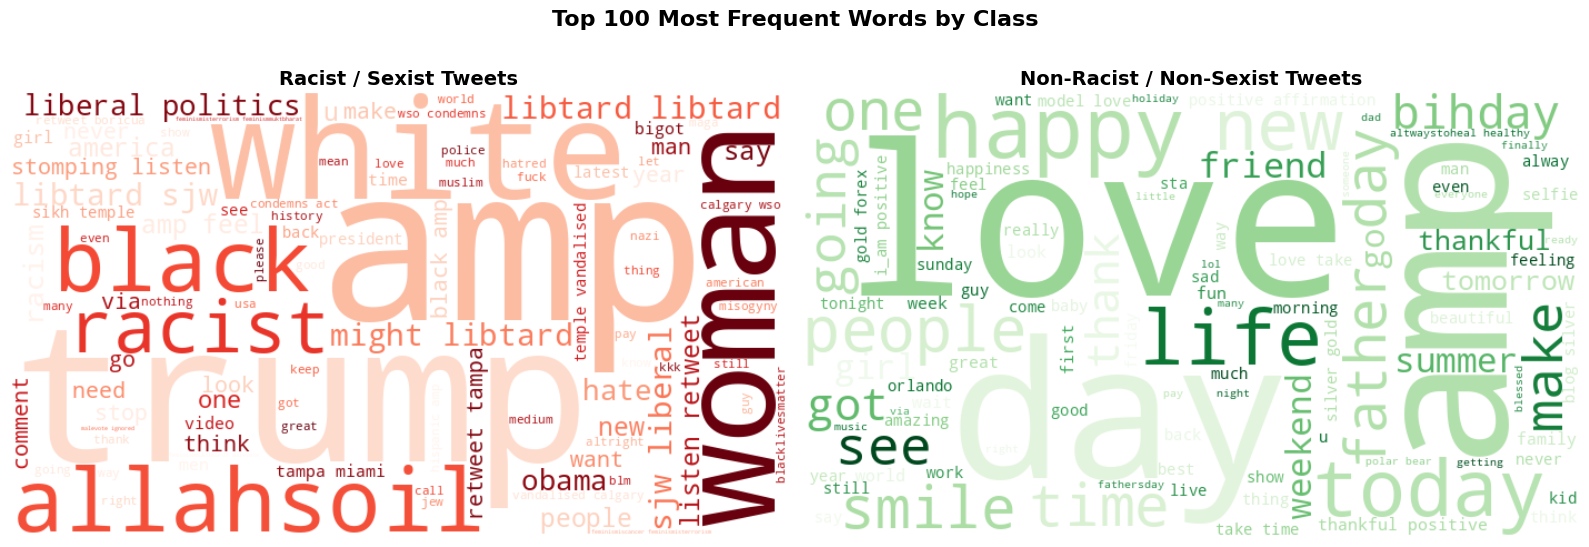

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label_val, title, color in zip(
        axes,
        [1, 0],
        ['Racist / Sexist Tweets', 'Non-Racist / Non-Sexist Tweets'],
        ['Reds', 'Greens']):
    text_subset = ' '.join(data[data['label'] == label_val]['cleaned_tweet'])
    wc = WordCloud(width=700, height=400, background_color='white',
                   max_words=100, colormap=color).generate(text_subset)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Top 100 Most Frequent Words by Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

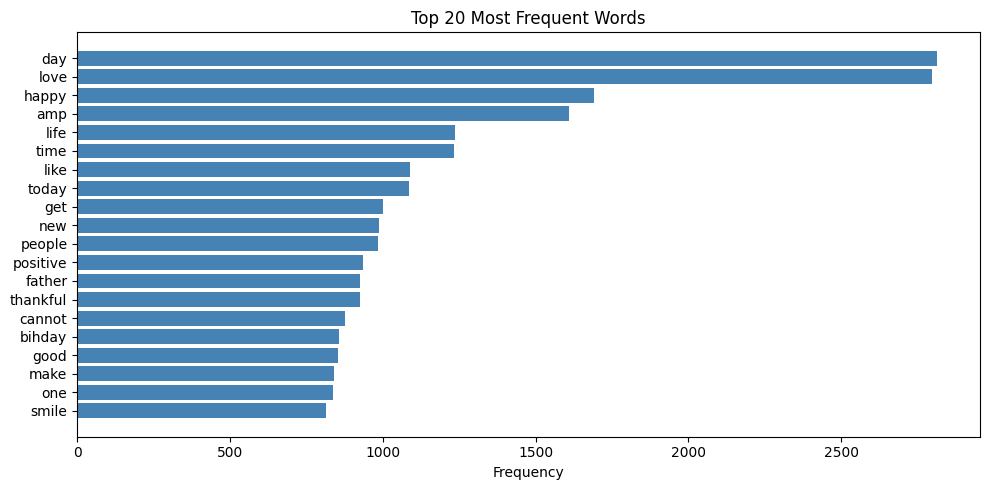

In [16]:
from collections import Counter

all_tokens = ' '.join(data['cleaned_tweet']).split()
word_freq  = Counter(all_tokens)
top_20     = word_freq.most_common(20)

words  = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

# Label Encoding

In [17]:
le = LabelEncoder()
data['label_enc'] = le.fit_transform(data['label'])
print("Label classes:", le.classes_)
print(data['label_enc'].value_counts())

Label classes: [0 1]
label_enc
0    29684
1     2238
Name: count, dtype: int64


#Train/Test Split

In [18]:
X = data['cleaned_tweet'].values
y = data['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTrain samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")


Train samples : 25537
Test  samples : 6385


# Tokenization

In [19]:
VOCAB_SIZE = 10_000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print(f"Vocabulary size (capped at {VOCAB_SIZE}): {len(tokenizer.word_index)} unique tokens")
print("Sample sequence:", X_train_seq[0][:15], "…")

Vocabulary size (capped at 10000): 32282 unique tokens
Sample sequence: [533, 1, 11, 533, 1, 3190] …


# Sequence Padding

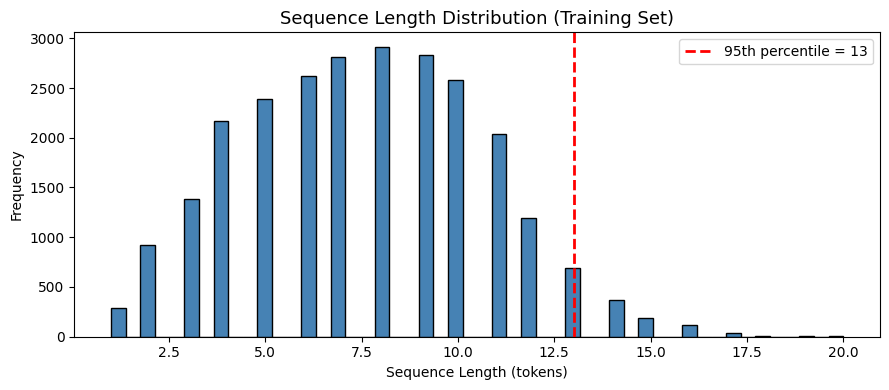


Using MAX_LEN = 13  (95th percentile)
X_train_pad shape : (25537, 13)
X_test_pad  shape : (6385, 13)


In [20]:
seq_lengths = [len(s) for s in X_train_seq]

plt.figure(figsize=(9, 4))
plt.hist(seq_lengths, bins=50, color='steelblue', edgecolor='black')
p95 = int(np.percentile(seq_lengths, 95))
plt.axvline(p95, color='red', linestyle='--', linewidth=2,
            label=f'95th percentile = {p95}')
plt.title('Sequence Length Distribution (Training Set)', fontsize=13)
plt.xlabel('Sequence Length (tokens)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

MAX_LEN = p95
print(f"\nUsing MAX_LEN = {MAX_LEN}  (95th percentile)")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

# Model 1: Simple RNN with Trainable Embedding

In [21]:
EMBED_DIM = 128
RNN_UNITS = 64

def build_rnn_model():
    model = Sequential(name='SimpleRNN_Model')
    model.add(Input(shape=(MAX_LEN,)))
    model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM))
    model.add(SimpleRNN(RNN_UNITS, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

rnn_model = build_rnn_model()
rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,465 (4.94 MB)

 Trainable params: 1,294,465 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

# Model 2: LSTM with Trainable Embedding

In [22]:
def build_lstm_model():
    model = Sequential(name='LSTM_Model')
    model.add(Input(shape=(MAX_LEN,)))
    model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM))
    model.add(LSTM(RNN_UNITS, activation='tanh', recurrent_dropout=0.2))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

lstm_model = build_lstm_model()
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()



Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,521 (5.08 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

# Loaded Pre-trained GLove Embeddings

In [23]:
embedding_model = gensim_api.load('glove-twitter-50')
GLOVE_DIM = 50

word_index    = tokenizer.word_index
actual_vocab  = min(VOCAB_SIZE, len(word_index) + 1)
embed_matrix  = np.zeros((actual_vocab, GLOVE_DIM))

hit, miss = 0, 0
for word, idx in word_index.items():
    if idx >= actual_vocab:
        continue
    if word in embedding_model:
        embed_matrix[idx] = embedding_model[word]
        hit += 1
    else:
        miss += 1

coverage = hit / (hit + miss) * 100
print(f"Embedding coverage : {coverage:.1f}%  ({hit} hits, {miss} misses)")

[==================================================] 100.0% 199.5/199.5MB downloaded
Embedding coverage : 88.9%  (8893 hits, 1106 misses)


# Model 3: LSTM with Fozen Glove Embedding

In [24]:
def build_lstm_glove_model():
    model = Sequential(name='LSTM_GloVe_Model')
    model.add(Input(shape=(MAX_LEN,)))
    model.add(Embedding(input_dim=actual_vocab,
                        output_dim=GLOVE_DIM,
                        weights=[embed_matrix],
                        trainable=False))
    model.add(LSTM(RNN_UNITS, activation='tanh', recurrent_dropout=0.2))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

lstm_glove_model = build_lstm_glove_model()
lstm_glove_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_glove_model.summary()


Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,553 (2.03 MB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

# Training Models

# Simple RNN

In [25]:
EPOCHS     = 15
BATCH_SIZE = 64
VAL_SPLIT  = 0.15
EPOCHS     = 15
BATCH_SIZE = 64
VAL_SPLIT  = 0.15

early_stop = EarlyStopping(monitor='val_loss', patience=3,
                           restore_best_weights=True, verbose=1)

print("Training Simple RNN")
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

Training Simple RNN
Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9418 - loss: 0.1864 - val_accuracy: 0.9551 - val_loss: 0.1358
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9761 - loss: 0.0794 - val_accuracy: 0.9590 - val_loss: 0.1283
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9900 - loss: 0.0328 - val_accuracy: 0.9564 - val_loss: 0.1506
Epoch 4/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9956 - loss: 0.0151 - val_accuracy: 0.9533 - val_loss: 0.1864
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9972 - loss: 0.0100 - val_accuracy: 0.9543 - val_loss: 0.1987
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


# LSTM

In [26]:
print("Training LSTM")
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

Training LSTM
Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9449 - loss: 0.1927 - val_accuracy: 0.9588 - val_loss: 0.1268
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9742 - loss: 0.0815 - val_accuracy: 0.9598 - val_loss: 0.1193
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9844 - loss: 0.0521 - val_accuracy: 0.9601 - val_loss: 0.1279
Epoch 4/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9883 - loss: 0.0380 - val_accuracy: 0.9593 - val_loss: 0.1319
Epoch 5/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.9915 - loss: 0.0278 - val_accuracy: 0.9569 - val_loss: 0.1678
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


# LSTM + Glove

In [27]:
print("Training LSTM And GloVe Embeddings")
history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

Training LSTM And GloVe Embeddings
Epoch 1/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9337 - loss: 0.1976 - val_accuracy: 0.9394 - val_loss: 0.1575
Epoch 2/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9431 - loss: 0.1590 - val_accuracy: 0.9457 - val_loss: 0.1422
Epoch 3/15
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9474 - loss: 0.1466 - val_accuracy: 0.9454 - val_loss: 0.1412
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


# Evaluation of all models

# Training vs Validation Curves

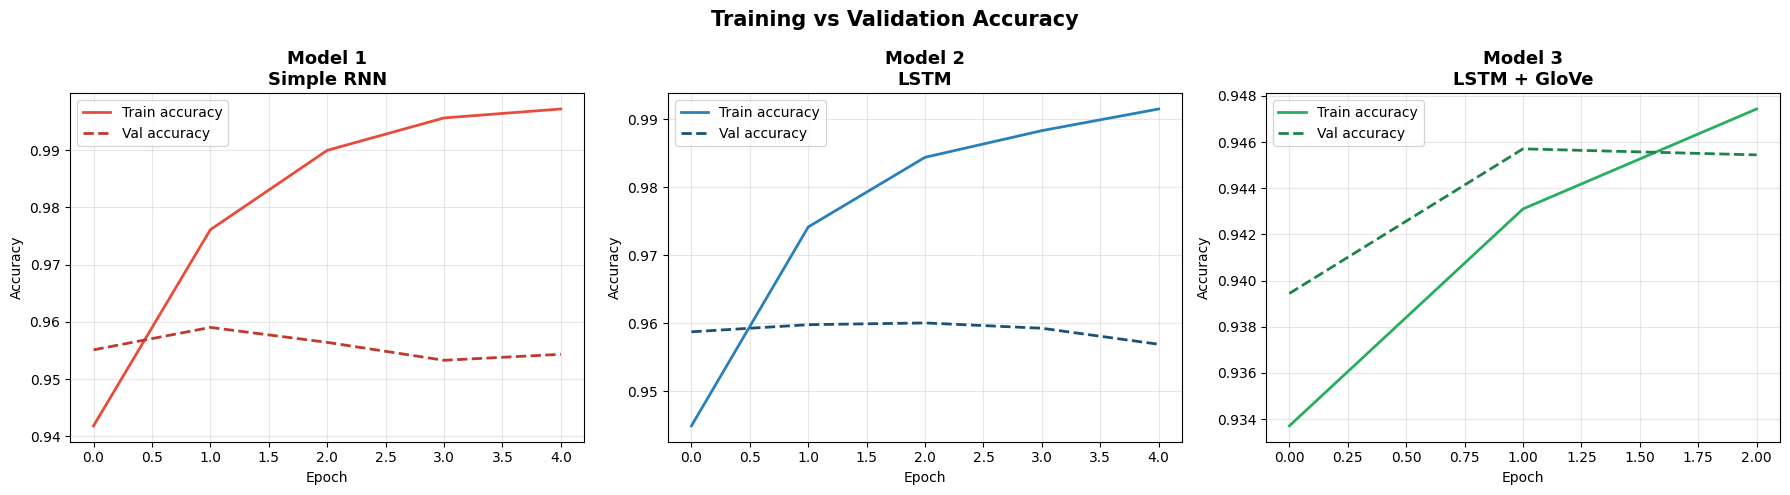

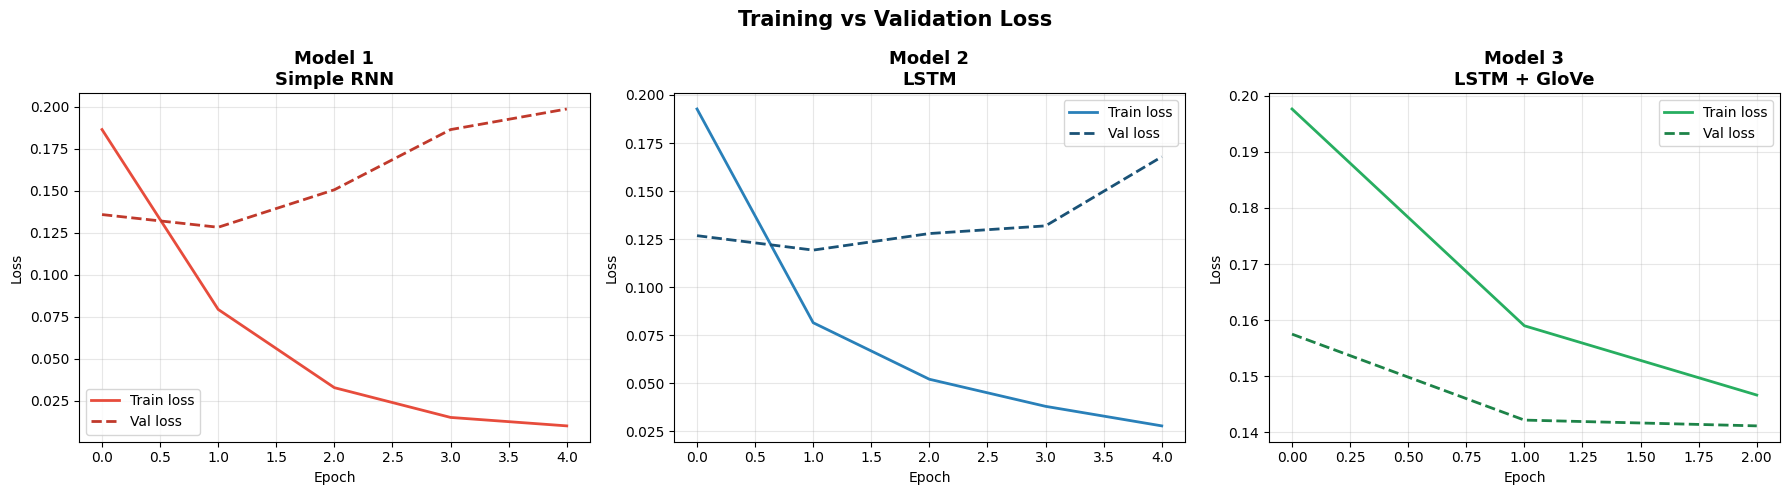

In [28]:
def plot_history(histories: dict, metric: str = 'accuracy'):
    """Plot training & validation curves for all models side by side."""
    fig, axes = plt.subplots(1, len(histories), figsize=(6 * len(histories), 5))
    if len(histories) == 1:
        axes = [axes]

    colors = [('#e74c3c','#c0392b'), ('#2980b9','#1a5276'), ('#27ae60','#1d8348')]
    for ax, (name, hist), (c_train, c_val) in zip(axes, histories.items(), colors):
        ax.plot(hist.history[metric],         color=c_train, label=f'Train {metric}', linewidth=2)
        ax.plot(hist.history[f'val_{metric}'], color=c_val,   label=f'Val {metric}',   linewidth=2, linestyle='--')
        ax.set_title(name, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(f'Training vs Validation {metric.capitalize()}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

histories = {
    'Model 1\nSimple RNN':   history_rnn,
    'Model 2\nLSTM':         history_lstm,
    'Model 3\nLSTM + GloVe': history_glove
}

plot_history(histories, metric='accuracy')
plot_history(histories, metric='loss')

# Evaluation

# Accuracy, Confusion matrix & Classification Report

  Evaluation: Simple RNN

Test Accuracy : 95.69%

Classification Report (Precision | Recall | F1-Score):
                       precision    recall  f1-score   support

Non-Racist/Sexist (0)     0.9712    0.9828    0.9770      5937
    Racist/Sexist (1)     0.7294    0.6138    0.6667       448

             accuracy                         0.9569      6385
            macro avg     0.8503    0.7983    0.8218      6385
         weighted avg     0.9542    0.9569    0.9552      6385



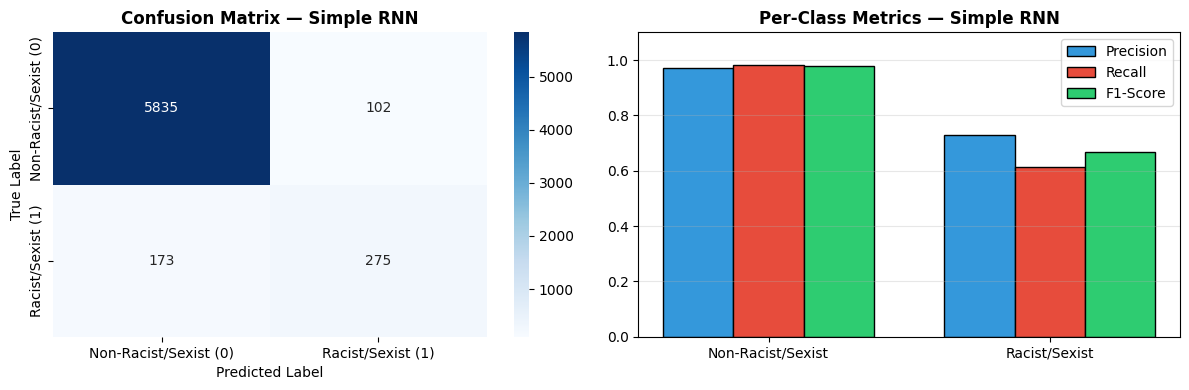

  Evaluation: LSTM

Test Accuracy : 96.16%

Classification Report (Precision | Recall | F1-Score):
                       precision    recall  f1-score   support

Non-Racist/Sexist (0)     0.9670    0.9926    0.9796      5937
    Racist/Sexist (1)     0.8488    0.5513    0.6685       448

             accuracy                         0.9616      6385
            macro avg     0.9079    0.7720    0.8241      6385
         weighted avg     0.9587    0.9616    0.9578      6385



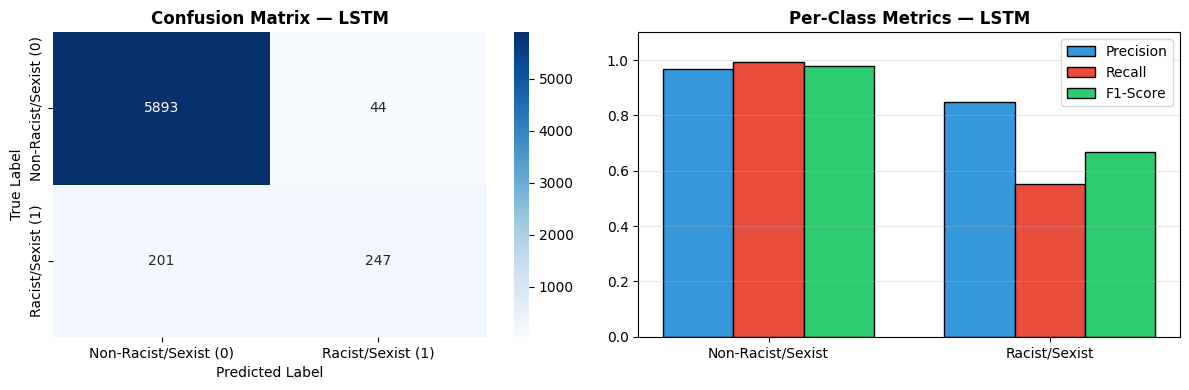

  Evaluation: LSTM + GloVe

Test Accuracy : 93.92%

Classification Report (Precision | Recall | F1-Score):
                       precision    recall  f1-score   support

Non-Racist/Sexist (0)     0.9474    0.9896    0.9680      5937
    Racist/Sexist (1)     0.6630    0.2723    0.3861       448

             accuracy                         0.9392      6385
            macro avg     0.8052    0.6309    0.6771      6385
         weighted avg     0.9275    0.9392    0.9272      6385



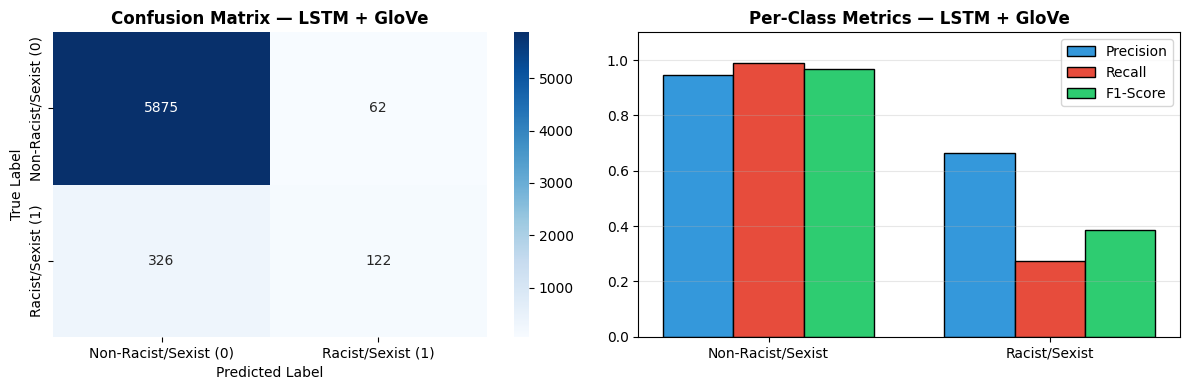

In [29]:
def evaluate_model(model, X_test_pad, y_test, model_name: str):
    print(f'  Evaluation: {model_name}')

    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = (y_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    print(f'\nTest Accuracy : {acc * 100:.2f}%')

    target_names = ['Non-Racist/Sexist (0)', 'Racist/Sexist (1)']

    print('\nClassification Report (Precision | Recall | F1-Score):')
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=target_names, yticklabels=target_names)
    axes[0].set_title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    metrics_vals = {
        'Precision': [precision_score(y_test, y_pred, pos_label=0),
                      precision_score(y_test, y_pred, pos_label=1)],
        'Recall':    [recall_score(y_test, y_pred, pos_label=0),
                      recall_score(y_test, y_pred, pos_label=1)],
        'F1-Score':  [f1_score(y_test, y_pred, pos_label=0),
                      f1_score(y_test, y_pred, pos_label=1)]
    }
    x = np.arange(2)
    width = 0.25
    bars_colors = ['#3498db', '#e74c3c', '#2ecc71']
    for j, (metric, vals) in enumerate(metrics_vals.items()):
        axes[1].bar(x + j*width, vals, width, label=metric, color=bars_colors[j], edgecolor='black')
    axes[1].set_xticks(x + width)
    axes[1].set_xticklabels(['Non-Racist/Sexist', 'Racist/Sexist'], fontsize=10)
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title(f'Per-Class Metrics — {model_name}', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    return acc, y_pred

acc1, pred1 = evaluate_model(rnn_model,        X_test_pad, y_test, 'Simple RNN')
acc2, pred2 = evaluate_model(lstm_model,       X_test_pad, y_test, 'LSTM')
acc3, pred3 = evaluate_model(lstm_glove_model, X_test_pad, y_test, 'LSTM + GloVe')


# Model Comparison Summary Table

In [36]:
models_list = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accs   = [acc1*100, acc2*100, acc3*100]
f1s    = [f1(y_test, pred1, average='macro')*100,
           f1(y_test, pred2, average='macro')*100,
           f1(y_test, pred3, average='macro')*100]

print('\nSummary Table')
summary_df = pd.DataFrame({
    'Model':    models_list,
    'Accuracy': [f'{a:.2f}%' for a in accs],
    'Macro F1': [f'{f:.2f}%' for f in f1s]
})
print(summary_df.to_string(index=False))


Summary Table
       Model Accuracy Macro F1
  Simple RNN   95.69%   82.18%
        LSTM   96.16%   82.41%
LSTM + GloVe   93.92%   67.71%


# Error Analysis

# Step1: Identity Misclassified

In [37]:
test_df_eval = pd.DataFrame({
    'original_tweet': data.iloc[
        train_test_split(range(len(data)), test_size=0.2,
                         random_state=42, stratify=y)[1]
    ]['tweet'].values,
    'cleaned_tweet': X_test,
    'true_label':    y_test,
    'pred_RNN':      pred1,
    'pred_LSTM':     pred2,
    'pred_GloVe':    pred3,
})

label_map = {0: 'Non-Racist/Sexist', 1: 'Racist/Sexist'}

misclassified = test_df_eval[test_df_eval['true_label'] != test_df_eval['pred_RNN']]

print(f"Total misclassified (Simple RNN) : {len(misclassified)} out of {len(test_df_eval)}")
print(f"Error rate                        : {len(misclassified)/len(test_df_eval)*100:.2f}%\n")

print('3 Sample Misclassified Examples:')
for _, row in misclassified.sample(min(3, len(misclassified)), random_state=1).iterrows():
    print(f"\n[Tweet]      : {str(row['original_tweet'])[:120]}")
    print(f"[Cleaned]    : {row['cleaned_tweet'][:100]}")
    print(f"[True Label] : {label_map[row['true_label']]}")
    print(f"[RNN pred]   : {label_map[row['pred_RNN']]}")
    print(f"[LSTM pred]  : {label_map[row['pred_LSTM']]}")
    print(f"[GloVe pred] : {label_map[row['pred_GloVe']]}")

Total misclassified (Simple RNN) : 275 out of 6385
Error rate                        : 4.31%

3 Sample Misclassified Examples:

[Tweet]      : @user @user lock the gate! #pamgelleheracist   #mmiw #mmiwg
[Cleaned]    : lock gate pamgelleheracist mmiw mmiwg
[True Label] : Racist/Sexist
[RNN pred]   : Non-Racist/Sexist
[LSTM pred]  : Non-Racist/Sexist
[GloVe pred] : Non-Racist/Sexist

[Tweet]      : @user @user he "has to play ball" now! the   state of our politics! it's now all a facade, as we've lost principality!
[Cleaned]    : play ball state politics facade lost principality
[True Label] : Non-Racist/Sexist
[RNN pred]   : Racist/Sexist
[LSTM pred]  : Racist/Sexist
[GloVe pred] : Non-Racist/Sexist

[Tweet]      : @user omfg i'm offended! i'm a  mailbox and i'm proud! #mailboxpride  #liberalisme
[Cleaned]    : omfg offended mailbox proud mailboxpride liberalisme
[True Label] : Racist/Sexist
[RNN pred]   : Non-Racist/Sexist
[LSTM pred]  : Non-Racist/Sexist
[GloVe pred] : Non-Racist/Sexi

# Step 2: Separate False Positive & False Negative

In [38]:
fp = misclassified[(misclassified['true_label']==0) & (misclassified['pred_RNN']==1)]
fn = misclassified[(misclassified['true_label']==1) & (misclassified['pred_RNN']==0)]


# Visualization

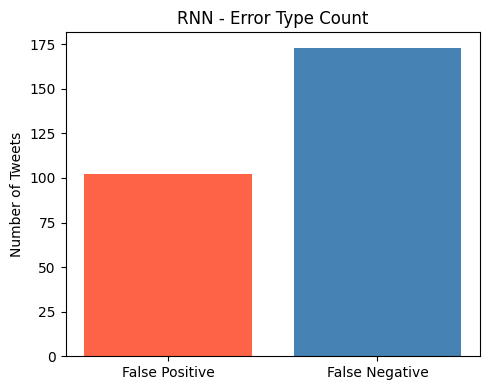

In [39]:
plt.figure(figsize=(5,4))
plt.bar(['False Positive', 'False Negative'], [len(fp), len(fn)], color=['tomato','steelblue'])
plt.title('RNN - Error Type Count')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

# Error Analysis

# Why does the model make these errors?

1. Sarcasm and Irony

Tweets like “oh great another woman driver” are often sarcastic, but this language doesn’t account for tone.

2. Short Tweets After Cleaning

I removed stopwords, URLs, mentions from the tweets. Some of the resulting tweets only contain 1-2 words, which is too little to correctly decide for the model.

3. Class Imbalance

My dataset has slightly more Non-Racist tweets than Racist/Sexist, thus my model is slightly biased to return the label "Non-Racist/Sexist" and is less accurate at identifying these type of tweets and causes more False Negatives.

4. Ambiguous Language

Some words can be racist in one context but not in another. The current model doesn’t understand context very well, especially the Simple RNN model which has a problem remembering long term patterns.

# Incorrect Predictions

Tweet: "lock gate pamgelleheracist mmiw mmiwg"

True Label: Racist/Sexist

RNN Predicted: Non-Racist/Sexist

LSTM Predicted: Non-Racist/Sexist

GloVe Predicted: Non-Racist/Sexist

Tweet: "omfg offended mailbox proud mailboxpride liberalisme"

True Label: Racist/Sexist

RNN Predicted: Non-Racist/Sexist

LSTM Predicted: Non-Racist/Sexist

GloVe Predicted: Non-Racist/Sexist

# Possible Reasons

After cleaning, hashtags like #mmiw #mmiwg (which are activist tags related to racism) lost their meaning. The model saw only lock gate and couldn't detect racism.

The tweet uses sarcasm (i'm a mailbox). After cleaning, context is completely lost and the model failed.

# Model Complexity vs Performance

Overall, increasing model complexity did not help for these cases. All three models struggled with hashtag-based and sarcastic tweets because meaning was lost during text cleaning.

# Real-Time Predictions with Gradio

In [41]:
import gradio as gr

def predict_tweet(tweet_text: str) -> str:
    if not tweet_text.strip():
        return 'Please enter a tweet.'

    cleaned = clean_text(tweet_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    def get_label(prob):
        label = 'Racist / Sexist' if prob >= 0.5 else 'Non-Racist / Non-Sexist'
        conf  = max(prob, 1 - prob) * 100
        return f'{label}  (confidence: {conf:.1f}%)'

    p1 = rnn_model.predict(padded, verbose=0)[0][0]
    p2 = lstm_model.predict(padded, verbose=0)[0][0]
    p3 = lstm_glove_model.predict(padded, verbose=0)[0][0]

    return (
        f'Cleaned Tweet     : {cleaned}\n\n'
        f'Model 1 - Simple RNN      : {get_label(p1)}\n'
        f'Model 2 - LSTM            : {get_label(p2)}\n'
        f'Model 3 - LSTM + GloVe    : {get_label(p3)}'
    )

demo = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(lines=3, placeholder='Enter a tweet here …', label='Tweet'),
    outputs=gr.Textbox(label='Prediction'),
    title='Racist / Sexist Tweet Detector',
    description='LSTM + GloVe model',
    examples=[
        ['I love how diverse and inclusive our community is!'],
        ['go back to your own country you dont belong here'],
        ['women should stay in the kitchen and not vote']
    ]
)
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://20d15852661907c25d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
